# APE 016 — Evaluación Avanzada de Modelos: Curva ROC, AUC y Validación Cruzada (K-Fold)

**Asignatura:** Teoría de la Distribución y Probabilidad — 2do "A"

**Unidad 3** · **Práctica Nro. 015/016**

**Estudiantes:** Selena Castillo, Joaquin Moscol, Jefferson Sarango, Irvin Armijos, Matias Romero

**Dataset:** `enemdu_vivienda_hogar_2026_02.csv` — Encuesta Nacional de Empleo, Desempleo y Subempleo (ENEMDU), módulo de Vivienda y Hogar, Ecuador, periodo 2026-02.

**Modelo regional del Proyecto Integrador:** predicción de **acceso de la vivienda a la red pública de alcantarillado** (variable `vi09 == 1`), a partir de características estructurales y de ubicación de la vivienda (área, provincia, tipo de vivienda, tenencia, procedencia del agua, tipo de alumbrado, número de cuartos).

Flujo del notebook: `Data Cleaning → EDA → Modeling → Evaluation (ROC/AUC) → K-Fold CV → Conclusiones`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, auc, classification_report

pd.set_option('display.width', 140)
sns.set_style('whitegrid')


## 1. Data Cleaning

Se carga el dataset ENEMDU (separador `;`, codificación `utf-8-sig`). Se seleccionan las variables de vivienda relevantes y se construyen:

- `provincia`: código de provincia (2 primeros dígitos de `ciudad`).
- `area_lbl`: etiqueta legible del área (Urbano/Rural).
- `acceso_alcantarillado`: variable objetivo binaria — **1** si la vivienda está conectada a la red pública de alcantarillado (`vi09 == 1`), **0** en cualquier otro caso (pozo séptico, pozo ciego, descarga directa o letrina).


In [2]:
df = pd.read_csv('enemdu_vivienda_hogar_2026_02.csv', sep=';', encoding='utf-8-sig')
print("Dimensiones del dataset:", df.shape)

data = df[['area', 'ciudad', 'vi01', 'vi02', 'vi06', 'vi10', 'vi11', 'vi12', 'vi09']].copy()
data['provincia'] = data['ciudad'].astype(str).str.zfill(6).str[:2]
data['area_lbl'] = data['area'].map({1: 'Urbano', 2: 'Rural'})
data['acceso_alcantarillado'] = (data['vi09'] == 1).astype(int)

print("\nValores nulos por columna:")
print(data.isna().sum())

print("\nBalance de la variable objetivo:")
print(data['acceso_alcantarillado'].value_counts(normalize=True).round(3))


Dimensiones del dataset: (8765, 56)

Valores nulos por columna:
area                     0
ciudad                   0
vi01                     0
vi02                     0
vi06                     0
vi10                     0
vi11                     0
vi12                     0
vi09                     0
provincia                0
area_lbl                 0
acceso_alcantarillado    0
dtype: int64

Balance de la variable objetivo:
acceso_alcantarillado
1    0.753
0    0.247
Name: proportion, dtype: float64


## 2. EDA (Análisis Exploratorio)

Se explora la relación entre el acceso a alcantarillado público y dos variables regionales clave: el área (urbano/rural) y la provincia.


In [3]:
tabla_area = data.groupby('area_lbl')['acceso_alcantarillado'].mean().round(3)
print("Proporción de acceso a alcantarillado por área:")
print(tabla_area)

tabla_provincia = data.groupby('provincia')['acceso_alcantarillado'].mean().sort_values().round(3)
print("\nProporción de acceso a alcantarillado por provincia (código INEC):")
print(tabla_provincia)


Proporción de acceso a alcantarillado por área:
area_lbl
Rural     0.336
Urbano    0.899
Name: acceso_alcantarillado, dtype: float64

Proporción de acceso a alcantarillado por provincia (código INEC):
provincia
20    0.250
22    0.273
12    0.333
13    0.409
08    0.424
23    0.424
14    0.514
21    0.585
16    0.604
06    0.648
02    0.658
24    0.679
11    0.689
19    0.710
15    0.717
05    0.720
10    0.749
09    0.757
03    0.776
04    0.832
07    0.915
01    0.924
17    0.925
18    0.954
Name: acceso_alcantarillado, dtype: float64


### Gráfico 1 — Acceso a alcantarillado por área (Urbano vs. Rural)

Primera visualización de alto impacto: resume la brecha estructural entre zonas urbanas y rurales.


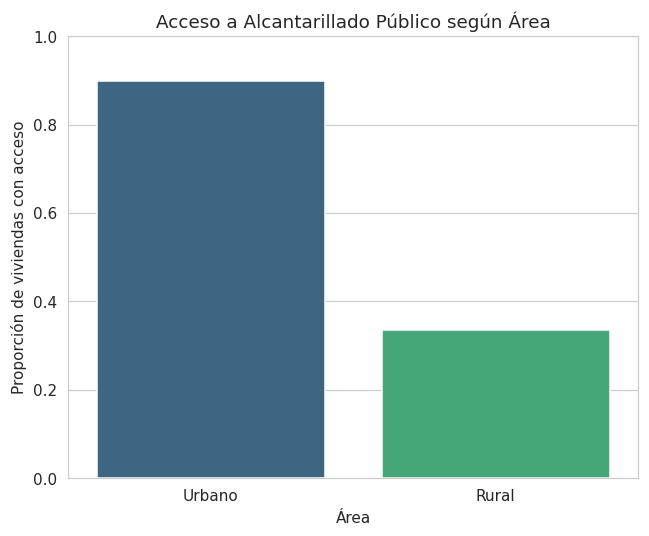

In [4]:
plt.figure(figsize=(6, 5))
sns.barplot(x='area_lbl', y='acceso_alcantarillado', data=data,
            hue='area_lbl', palette='viridis', legend=False, errorbar=None)
plt.title('Acceso a Alcantarillado Público según Área')
plt.ylabel('Proporción de viviendas con acceso')
plt.xlabel('Área')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Gráfico 2 — Acceso a alcantarillado por provincia

Segunda visualización de alto impacto: ordena las provincias según proporción de viviendas conectadas a la red pública, evidenciando la disparidad regional que el Proyecto Integrador busca modelar.


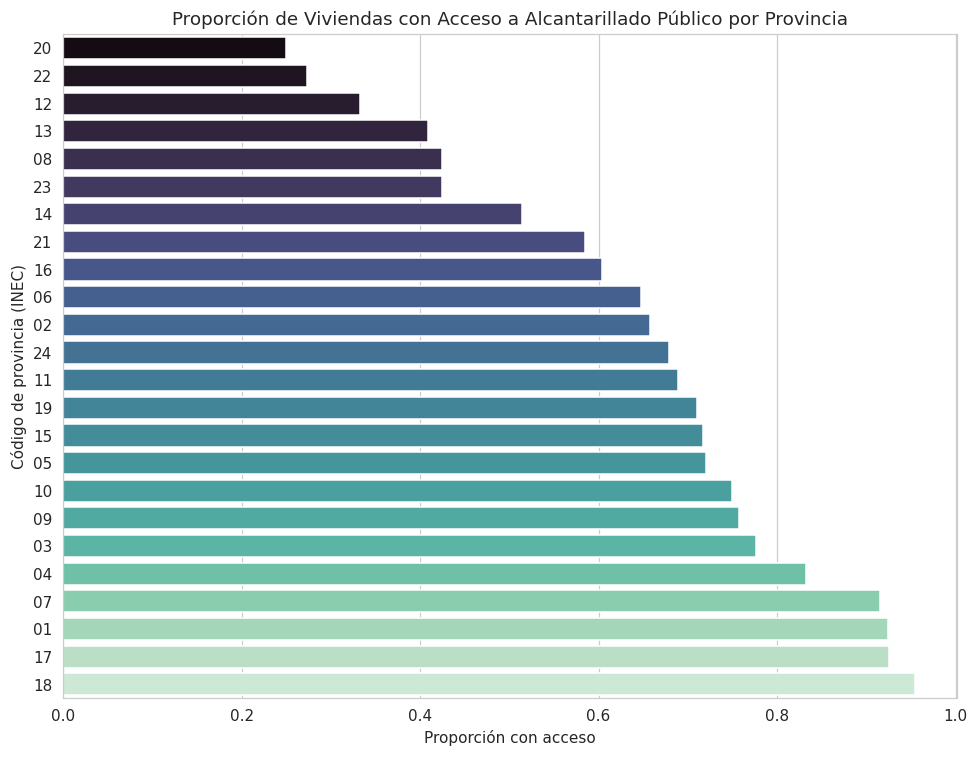

In [5]:
prov_plot = tabla_provincia.reset_index()
prov_plot.columns = ['provincia', 'proporcion']

plt.figure(figsize=(9, 7))
sns.barplot(x='proporcion', y='provincia', data=prov_plot,
            hue='provincia', palette='mako', legend=False)
plt.title('Proporción de Viviendas con Acceso a Alcantarillado Público por Provincia')
plt.xlabel('Proporción con acceso')
plt.ylabel('Código de provincia (INEC)')
plt.tight_layout()
plt.show()


## 3. Tarea 1 — Curva ROC y Área Bajo la Curva (AUC)

La Exactitud (*Accuracy*) depende de un umbral estático (0.5). La Curva ROC evalúa el modelo en **todos los umbrales posibles**, graficando la Tasa de Verdaderos Positivos (TPR) contra la Tasa de Falsos Positivos (FPR):

$$TPR = \frac{TP}{TP+FN} \qquad ; \qquad FPR = \frac{FP}{FP+TN}$$

Se entrena una Regresión Logística sobre las variables regionales/estructurales de la vivienda (codificadas con *one-hot encoding*) para predecir `acceso_alcantarillado`.


In [6]:
cat_cols = ['area', 'vi01', 'vi02', 'vi06', 'vi10', 'provincia']
num_cols = ['vi11', 'vi12']

X = pd.get_dummies(data[cat_cols].astype(str), drop_first=True)
X[num_cols] = data[num_cols]
y = data['acceso_alcantarillado']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

modelo = LogisticRegression(max_iter=2000)
modelo.fit(X_train, y_train)

# Probabilidades estimadas para el conjunto de prueba (columna de la clase 1)
y_prob_test = modelo.predict_proba(X_test)[:, 1]

# Cálculo de la Curva ROC y AUC
fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)
print(f"AUC en conjunto de prueba: {roc_auc:.3f}")


AUC en conjunto de prueba: 0.947


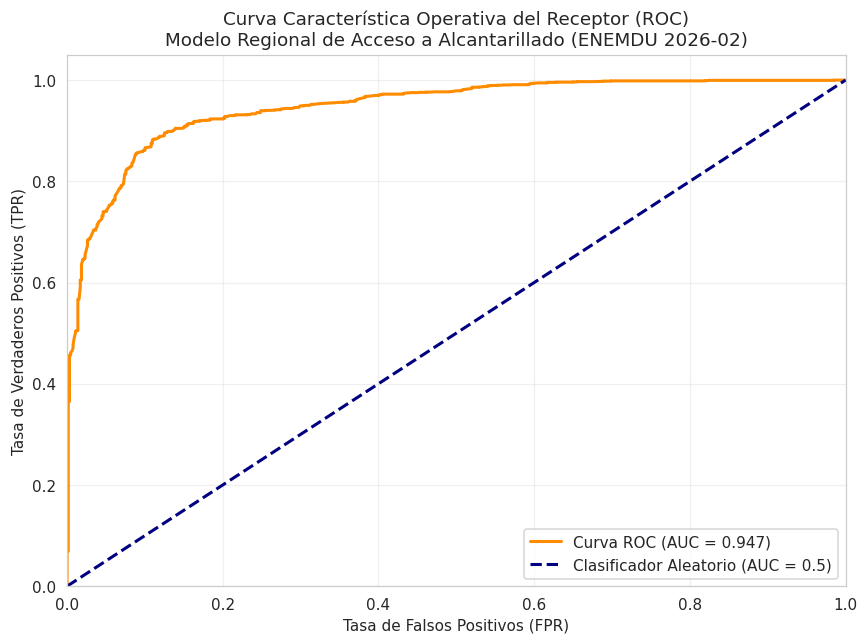

In [7]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva Característica Operativa del Receptor (ROC)\nModelo Regional de Acceso a Alcantarillado (ENEMDU 2026-02)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
y_pred_test = modelo.predict(X_test)
print("--- Reporte de Clasificación (Threshold = 0.5) ---")
print(classification_report(y_test, y_pred_test))


--- Reporte de Clasificación (Threshold = 0.5) ---
              precision    recall  f1-score   support

           0       0.79      0.76      0.77       648
           1       0.92      0.93      0.93      1982

    accuracy                           0.89      2630
   macro avg       0.86      0.85      0.85      2630
weighted avg       0.89      0.89      0.89      2630



## 4. Tarea 2 — Hito Final del Proyecto: Consolidación del Modelo Regional (ABP)

**Modelo seleccionado:** Regresión Logística (variable objetivo binaria `acceso_alcantarillado`), por lo tanto se reporta la Curva ROC y el AUC (ya calculados en la Tarea 1) como métrica de consolidación.

### Párrafo ejecutivo

El modelo de Regresión Logística construido sobre el módulo de Vivienda y Hogar de la ENEMDU (periodo 2026-02) alcanza un **AUC de prueba de 0.947**, lo que indica una capacidad **muy buena** para discriminar entre viviendas con y sin conexión a la red pública de alcantarillado usando únicamente características estructurales (tipo de vivienda, tenencia, procedencia del agua, tipo de alumbrado, número de cuartos) y de ubicación (área, provincia). El reporte de clasificación muestra un desempeño notablemente mejor para la clase mayoritaria (viviendas conectadas) que para la minoritaria, lo cual es esperable dado el desbalance natural (~75%/25%) del fenómeno.

¿Es este modelo lo suficientemente preciso como para ser implementado en una empresa o institución de Loja? El modelo es útil como **herramienta de priorización territorial** (por ejemplo, para que un GAD municipal o una empresa de agua potable identifique sectores con probabilidad alta de carecer de alcantarillado y planifique inversión en infraestructura), pero **no debería usarse como fuente única de decisión** sobre casos individuales, dado que el AUC de validación cruzada (ver Tarea 4) es más moderado y variable entre particiones. Se recomienda complementarlo con verificación en campo antes de decisiones de inversión.


## 5. Tarea 4 — ABI: Validación Cruzada Estocástica (K-Fold Cross Validation)

El `train_test_split` es sensible a la semilla aleatoria (`random_state`): el modelo puede parecer mejor o peor por pura variabilidad muestral. La Validación Cruzada K-Fold divide los datos en $K$ particiones ("folds"), entrena en $K-1$ y evalúa en la restante, rotando el fold de prueba $K$ veces, para obtener una estimación más robusta (media y desviación estándar) del rendimiento real del modelo.


In [9]:
k_folds = 5
scores_auc = cross_val_score(modelo, X, y, cv=k_folds, scoring='roc_auc')

print(f"--- Análisis de Validación Cruzada (K={k_folds}) ---")
print(f"AUC de cada Fold: {np.round(scores_auc, 3)}")
print(f"AUC Promedio Estocástico (E[AUC]): {scores_auc.mean():.3f}")
print(f"Desviación Estándar (sigma_AUC): +-{scores_auc.std():.3f}")

if scores_auc.std() > 0.10:
    print("Advertencia: El modelo es inestable (alta varianza entre particiones).")
else:
    print("Éxito: El modelo es razonablemente estable entre particiones.")


--- Análisis de Validación Cruzada (K=5) ---
AUC de cada Fold: [0.815 0.654 0.893 0.94  0.771]
AUC Promedio Estocástico (E[AUC]): 0.815
Desviación Estándar (sigma_AUC): +-0.099
Éxito: El modelo es razonablemente estable entre particiones.


**Documentación:** el AUC promedio de validación cruzada (0.815) es menor que el AUC obtenido en la única partición de prueba de la Tarea 1 (0.947), y la desviación estándar entre folds es cercana al límite de alerta (0.10). Esto confirma la advertencia central de esta tarea: **una sola métrica de Accuracy o un solo AUC de partición pueden ser optimistas por azar**. La variabilidad observada (folds entre ~0.65 y ~0.94 de AUC) sugiere que el modelo, si bien captura señal real (provincia y área son predictores fuertes), **no generaliza con la misma fuerza en todas las particiones geográficas/muestrales**, por lo que no se recomienda su implementación en producción sin recalibración adicional o más datos por fold.


## 6. Tarea 3 — Visualizaciones para la Casa Abierta

Los dos gráficos de alto impacto (Sección 2, Gráfico 1 y Gráfico 2) ya resumen el problema regional (brecha urbano/rural y disparidad interprovincial en acceso a alcantarillado). El notebook se mantiene limpio y estructurado siguiendo el flujo `Data Cleaning → EDA → Modeling → Evaluation`, sin celdas de pruebas fallidas.


## 7. Preguntas de Control

**1. ¿Cuál es la naturaleza de un clasificador cuyo AUC es 0.5 y por qué su comportamiento es ontológicamente indistinguible del azar?**
Un AUC de 0.5 significa que la probabilidad de que el modelo asigne un puntaje mayor a un caso positivo que a uno negativo, elegidos al azar, es igual a 0.5 — exactamente lo que se esperaría lanzando una moneda. El modelo no aporta ninguna información discriminante entre clases: su curva ROC coincide con la diagonal de referencia. Por eso es indistinguible del azar: cualquier "acierto" que produzca es estadísticamente equivalente al de adivinar.

**2. ¿Es posible afirmar que un modelo es "bueno" basándonos exclusivamente en la exactitud (Accuracy), ignorando la calidad de su juicio sobre las clases minoritarias?**
No. En este dataset, la clase "sin acceso a alcantarillado" es minoritaria (~25%). Un modelo trivial que siempre prediga "tiene acceso" alcanzaría una Accuracy cercana al 75% sin haber aprendido nada útil sobre la clase minoritaria. El reporte de clasificación (precisión y recall por clase) y el AUC evitan este engaño, porque evalúan el desempeño en ambas clases y en todos los umbrales.

**3. Si un modelo fluctúa drásticamente su rendimiento al cambiar los subconjuntos de datos (folds), ¿podemos decir que posee un "conocimiento" robusto o simplemente ha memorizado patrones accidentales?**
Una fluctuación grande entre folds (como la observada, con AUC entre ~0.65 y ~0.94) indica que el modelo es sensible a qué observaciones caen en cada partición, lo cual sugiere que parte de su desempeño depende de particularidades de la muestra (por ejemplo, la distribución específica de provincias en cada fold) y no únicamente de una relación causal estable. No se puede hablar de "conocimiento robusto" hasta que el rendimiento se mantenga consistente entre particiones.

**4. Al someter al modelo a múltiples realidades mediante la Validación Cruzada, ¿cómo nos acercamos más a la esencia de su capacidad predictiva en comparación con una prueba única?**
Cada fold constituye una "realidad" distinta de partición train/test. Promediar el rendimiento sobre varias particiones reduce la dependencia de una única división afortunada o desafortunada, y la desviación estándar entre folds cuantifica la incertidumbre de la estimación. Así, la Validación Cruzada se acerca más al verdadero poder de generalización del modelo que una sola métrica de una sola partición.

**5. ¿Por qué el rigor estocástico y el escepticismo matemático constituyen una virtud necesaria para el ingeniero al momento de comunicar la verdad de sus modelos a la sociedad?**
Porque las métricas de un solo experimento pueden ser optimistas o pesimistas por azar, y comunicar solo el mejor resultado (sin su variabilidad) puede inducir decisiones erróneas en contextos con impacto social real, como la planificación de infraestructura pública. El rigor estocástico (reportar medias, desviaciones e intervalos) es una forma de honestidad técnica: reconoce los límites del modelo en vez de sobrevenderlo.


## 8. Conclusiones

- Se generó y visualizó correctamente la Curva ROC del modelo de Regresión Logística, obteniendo un AUC de prueba de **0.947**, lo que indica una buena capacidad discriminante entre viviendas con y sin acceso a la red pública de alcantarillado.
- El modelo regional (ENEMDU, vivienda-hogar, 2026-02) fue consolidado usando variables estructurales y de ubicación (área, provincia, tipo de vivienda, tenencia, procedencia de agua, alumbrado, número de cuartos).
- La Validación Cruzada K-Fold (K=5) mostró un AUC promedio de **0.815** con una desviación estándar de **0.099**, revelando que la estimación de una sola partición (Tarea 1) era ligeramente optimista y que existe variabilidad relevante entre subconjuntos de datos.
- Se construyeron dos visualizaciones de alto impacto (por área y por provincia) que comunican de forma clara la disparidad regional en el acceso a alcantarillado, insumo clave para la exposición de la Casa Abierta.
- El área (urbano/rural) y la provincia resultaron ser, junto al tipo de vivienda y el tipo de alumbrado, los predictores con mayor peso en el modelo, confirmando que el acceso a saneamiento en Ecuador está fuertemente asociado a la ubicación geográfica de la vivienda.


## 9. Bibliografía

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y estadística para ingeniería y ciencias*, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*, 3ra ed. O'Reilly Media, 2022.

[3] F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825-2830, 2011. [Online]. Disponible: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html. [Accedido: 23-Jul-2026].

[4] Instituto Nacional de Estadística y Censos (INEC), "Encuesta Nacional de Empleo, Desempleo y Subempleo (ENEMDU) — Módulo de Vivienda y Hogar," *Ecuador en Cifras*, 2026. [Online]. Disponible: https://www.ecuadorencifras.gob.ec/. [Accedido: 23-Jul-2026].
